In [1]:
import pandas as pd

df = pd.read_csv("Unemployment_in_India[1].csv")

print("Shape:", df.shape)

display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [2]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Remove rows with missing values
df = df.dropna()

print("Shape after cleaning:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape after cleaning: (740, 7)

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object


In [3]:
# Average unemployment rate by region

region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


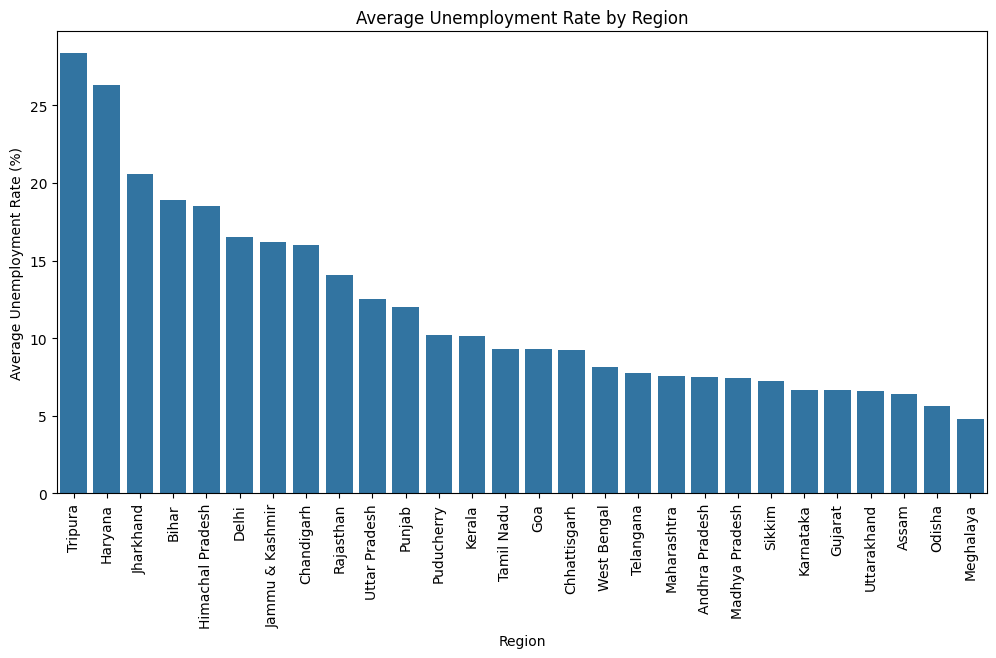

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    x=region_avg.index,
    y=region_avg.values
)

plt.xticks(rotation=90)
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Average Unemployment Rate by Region")
plt.show()

### Observation

The average unemployment rate varies across different regions of India. Some regions have considerably higher unemployment rates than others, indicating differences in employment opportunities and labour-market conditions. This regional variation can help identify areas that may require greater employment support and policy attention.

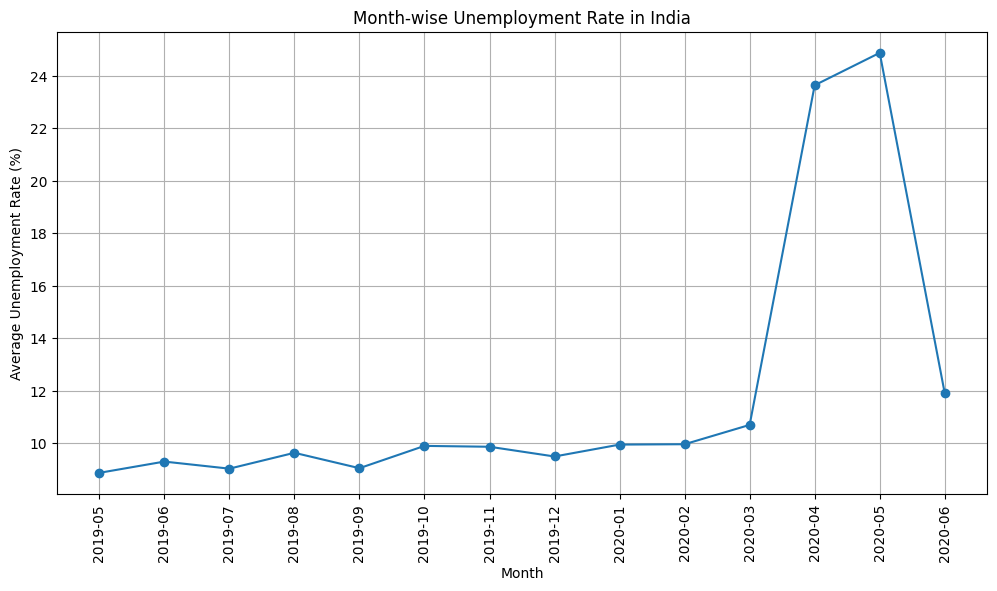

In [5]:
# Month-wise average unemployment rate

monthly_avg = df.groupby(df['Date'].dt.to_period('M'))[
    'Estimated Unemployment Rate (%)'
].mean()

monthly_avg.index = monthly_avg.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Month-wise Unemployment Rate in India")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

### Observation

The unemployment rate shows noticeable fluctuations over time. The trend is not constant, with some months showing higher unemployment rates and others showing lower rates. The changes become particularly important around the COVID-19 period, when employment conditions were significantly affected.

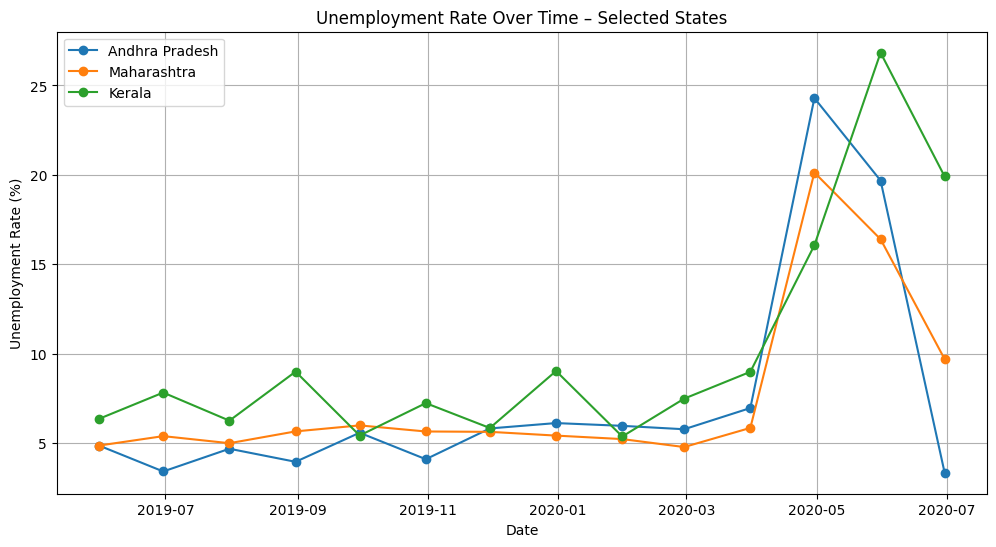

In [6]:
# Select three major states for comparison

states = ['Andhra Pradesh', 'Maharashtra', 'Kerala']

state_data = df[df['Region'].isin(states)]

plt.figure(figsize=(12, 6))

for state in states:
    state_monthly = state_data[state_data['Region'] == state].groupby('Date')[
        'Estimated Unemployment Rate (%)'
    ].mean()

    plt.plot(state_monthly.index, state_monthly.values, marker='o', label=state)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time – Selected States")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The unemployment rates of Andhra Pradesh, Maharashtra, and Kerala fluctuate over time. Each state shows a different pattern, indicating that unemployment was not uniform across regions. The changes during the COVID-19 period are particularly noticeable.

In [7]:
# Top 10 states with highest average unemployment rate

top_10_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

print(top_10_states)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


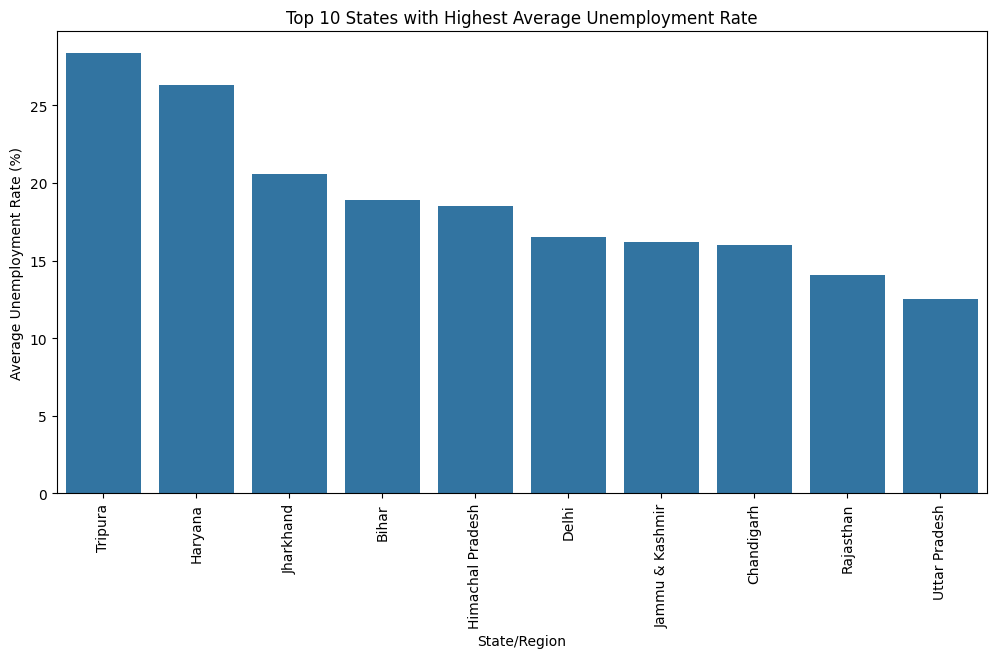

In [8]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_states.index,
    y=top_10_states.values
)

plt.xticks(rotation=90)
plt.xlabel("State/Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.show()

### Observation

The top 10 regions show noticeably higher average unemployment rates compared with other regions. This indicates that unemployment varies considerably across India, highlighting regions where employment opportunities and support measures may need greater attention.

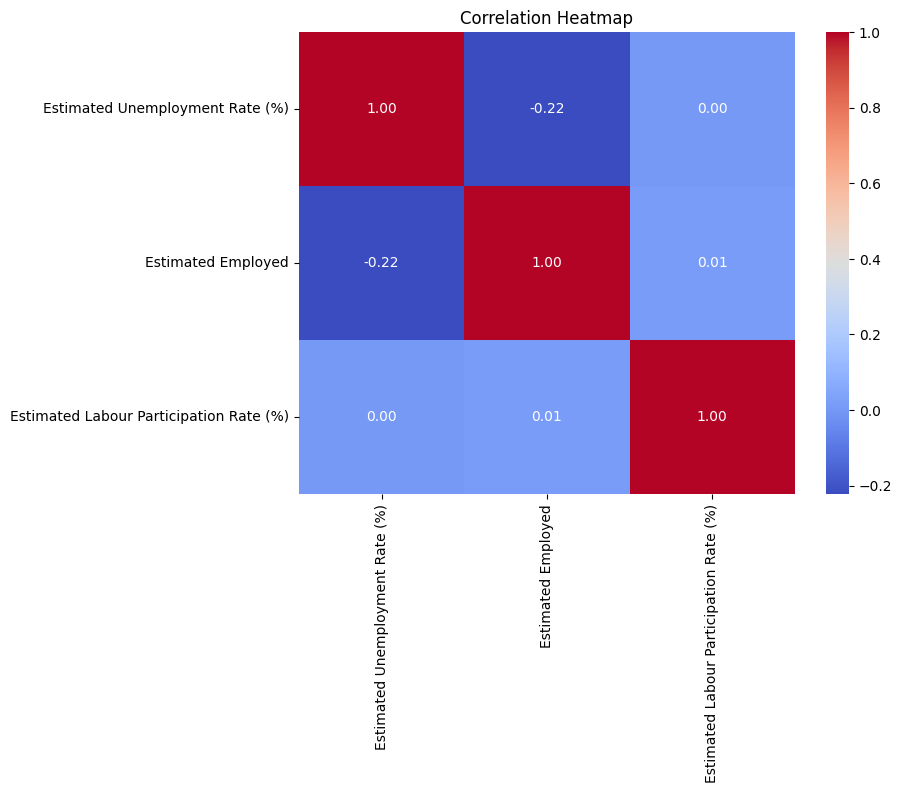

In [9]:
# Correlation between unemployment, employment and labour participation

corr = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap shows the correlation between unemployment rate, estimated employment, and labour participation rate. The correlation values help identify whether changes in one variable are associated with changes in another. Stronger positive or negative values indicate a stronger relationship, while values closer to zero indicate a weaker relationship.

In [11]:
# Split the data into pre-COVID and post-COVID periods

pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

pre_covid_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_avg = post_covid['Estimated Unemployment Rate (%)'].mean()

print("Pre-COVID average unemployment rate:", round(pre_covid_avg, 2), "%")
print("Post-COVID average unemployment rate:", round(post_covid_avg, 2), "%")

Pre-COVID average unemployment rate: 9.51 %
Post-COVID average unemployment rate: 17.77 %


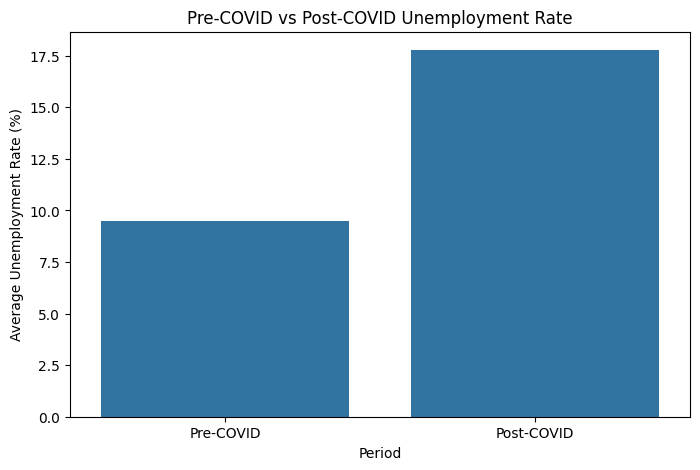

In [12]:
# Pre-COVID vs Post-COVID unemployment rate

periods = ['Pre-COVID', 'Post-COVID']
rates = [pre_covid_avg, post_covid_avg]

plt.figure(figsize=(8, 5))

sns.barplot(x=periods, y=rates)

plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.show()

### Observation

The comparison shows a difference between the average unemployment rates before and after the COVID-19 period. The post-COVID average indicates how unemployment conditions changed following the onset of the pandemic. This comparison highlights the significant impact that the pandemic period had on employment conditions in India.

## Conclusion

The analysis of unemployment data in India reveals significant variation across regions and over time. The unemployment rate fluctuated during the study period, with noticeable changes around the COVID-19 period.

### Key Insights

1. Unemployment rates vary considerably across different states and regions.
2. Monthly trends show fluctuations in unemployment over time.
3. The three-state comparison shows that each region experienced different unemployment patterns.
4. The top 10 analysis identifies regions with comparatively higher average unemployment rates.
5. The Pre-COVID vs Post-COVID comparison highlights changes in unemployment conditions during the pandemic period.

### Actionable Recommendations

1. Focus employment-support programs on regions with consistently higher unemployment rates.
2. Provide skill-development and training programs to improve employability.
3. Use regional and monthly unemployment trends to plan targeted employment policies.
4. Encourage industries and businesses to create more employment opportunities in high-unemployment regions.